# Customer Segmentation Analysis Using K-Means Clustering

## Objective
The objective of this project is to segment e-commerce customers based on their purchasing behaviour using RFM (Recency, Frequency, Monetary) analysis and K-Means clustering.

The analysis identifies distinct customer groups and provides targeted marketing recommendations for each segment.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.preprocessing import StandardScaler 
from sklearn.cluster import KMeans 
from sklearn.metrics import silhouette_score
import warnings 
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv("C:/Users/asind/Downloads/archive (3)/online_retail.csv")

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.shape

(541909, 8)

In [5]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [7]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(5268)

# Clean the Dataset

In [9]:
df = df.dropna(subset=['CustomerID'])

In [10]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [11]:
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

In [12]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  object        
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[ns]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  float64       
 7   Country      397884 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.3+ MB


# Create Total Purchase Value

In [14]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [15]:
df[['Quantity', 'UnitPrice', 'TotalPrice']].head()

,Quantity,UnitPrice,TotalPrice
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


# RFM Analysis

## We need to calculate :
 Recency,
 Frequency,
 Monetary

In [16]:
analysis_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [17]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (analysis_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

In [18]:
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalPrice': 'Monetary'
}, inplace=True)

In [19]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


# Descriptive Statistics

In [20]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


In [21]:
print("Average Recency:", rfm['Recency'].mean())
print("Average Frequency:", rfm['Frequency'].mean())
print("Average Monetary Value:", rfm['Monetary'].mean())

Average Recency: 92.53642231443061
Average Frequency: 4.272014753342554
Average Monetary Value: 2054.2664601198708


In [22]:
average_purchase_value = df['TotalPrice'].sum() / df['InvoiceNo'].nunique()

print("Average Purchase Value:", average_purchase_value)

Average Purchase Value: 480.8659563997409


In [23]:
average_purchase_frequency = rfm['Frequency'].mean()

print("Average Purchase Frequency:", average_purchase_frequency)

Average Purchase Frequency: 4.272014753342554


In [24]:
customer_lifetime_value = rfm['Monetary'].mean()

print("Average Customer Lifetime Value:", customer_lifetime_value)

Average Customer Lifetime Value: 2054.2664601198708


# Visualise RFM Distributions

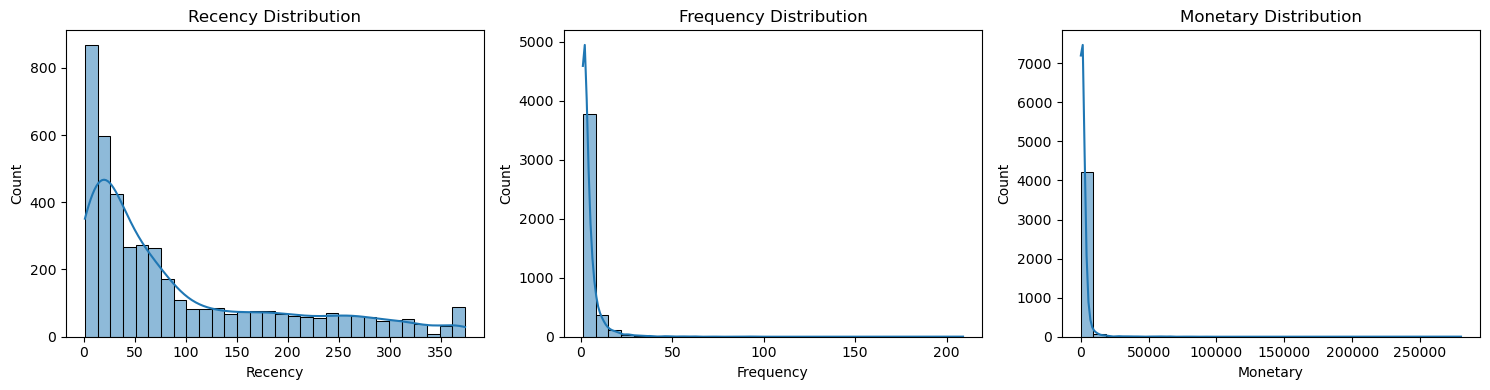

In [25]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
sns.histplot(rfm['Recency'], bins=30, kde=True)
plt.title('Recency Distribution')

plt.subplot(1, 3, 2)
sns.histplot(rfm['Frequency'], bins=30, kde=True)
plt.title('Frequency Distribution')

plt.subplot(1, 3, 3)
sns.histplot(rfm['Monetary'], bins=30, kde=True)
plt.title('Monetary Distribution')

plt.tight_layout()
plt.show()

# Standardise the Data

In [26]:
features = rfm[['Recency', 'Frequency', 'Monetary']]

In [27]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(features)

In [28]:
rfm_scaled_df = pd.DataFrame(
    rfm_scaled,
    columns=['Recency', 'Frequency', 'Monetary'],
    index=rfm.index
)

rfm_scaled_df.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,2.334574,-0.425097,8.358668
12347.0,-0.905340,0.354417,0.250966
12348.0,-0.175360,-0.035340,-0.028596
12349.0,-0.735345,-0.425097,-0.033012
12350.0,2.174578,-0.425097,-0.191347


# Find Optimal K Using Elbow Method

In [29]:
inertia = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

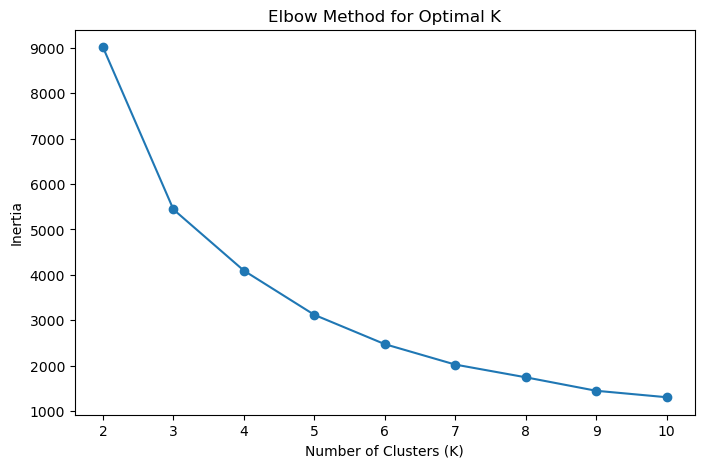

In [30]:
plt.figure(figsize=(8, 5))

plt.plot(K_range, inertia, marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')

plt.show()

In [31]:
optimal_k = 3

In [32]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [33]:
rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,0
12347.0,2,7,4310.00,1
12348.0,75,4,1797.24,1
12349.0,19,1,1757.55,1
12350.0,310,1,334.40,0


# Quality of Clustering

In [34]:
silhouette_avg = silhouette_score(
    rfm_scaled,
    rfm['Cluster']
)

print("Silhouette Score:", silhouette_avg)

Silhouette Score: 0.5941879366550106


# Visualising Clusters

# Recency vs Frequency

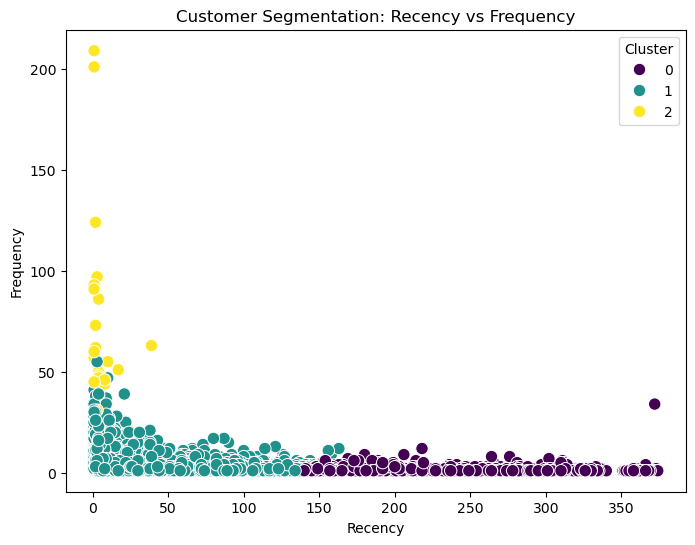

In [35]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Frequency',
    hue='Cluster',
    palette='viridis',
    s=80
)

plt.title('Customer Segmentation: Recency vs Frequency')
plt.xlabel('Recency')
plt.ylabel('Frequency')

plt.show()

# Frequency vs Monetary

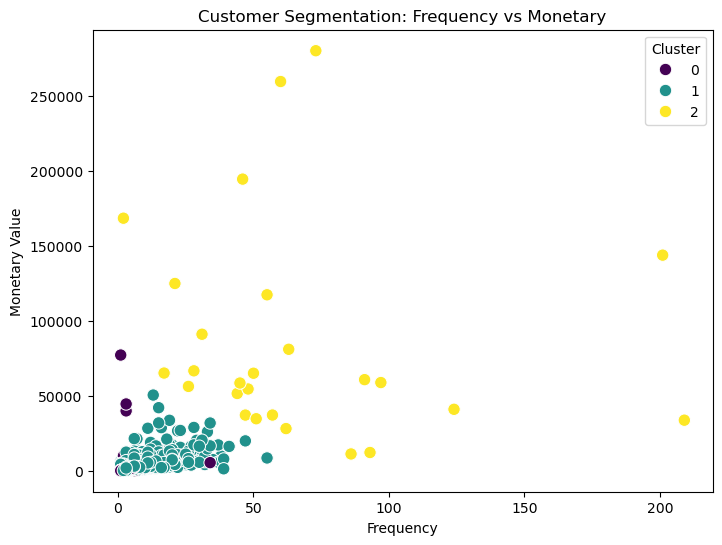

In [36]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='viridis',
    s=80
)

plt.title('Customer Segmentation: Frequency vs Monetary')
plt.xlabel('Frequency')
plt.ylabel('Monetary Value')

plt.show()

# Profiling Each Clusters

In [37]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (analysis_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

In [38]:
rfm.columns

Index(['InvoiceDate', 'InvoiceNo', 'TotalPrice'], dtype='object')

In [39]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [40]:
rfm.head()

,InvoiceDate,InvoiceNo,TotalPrice,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,0
12347.0,2,7,4310.00,1
12348.0,75,4,1797.24,1
12349.0,19,1,1757.55,1
12350.0,310,1,334.40,0


In [41]:
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalPrice': 'Monetary'
}, inplace=True)

In [42]:
rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,0
12347.0,2,7,4310.00,1
12348.0,75,4,1797.24,1
12349.0,19,1,1757.55,1
12350.0,310,1,334.40,0


In [43]:
cluster_profile = rfm.groupby('Cluster').agg(
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    CustomerCount=('Cluster', 'size')
)

cluster_profile = cluster_profile.sort_index()

cluster_profile

,Avg_Recency,Avg_Frequency,Avg_Monetary,CustomerCount
Cluster,,,,
0,247.106285,1.582255,631.424206,1082
1,41.454180,4.672755,1855.942345,3230
2,6.038462,66.423077,85904.351538,26


# Name Your Customer Segments


# Bar Chart

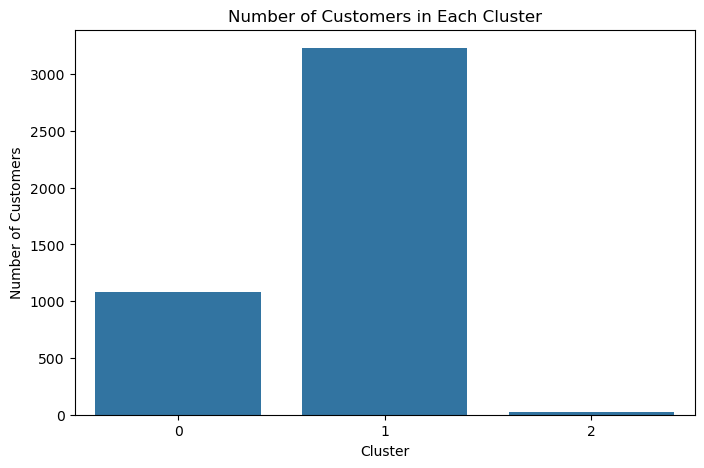

In [44]:
cluster_counts = rfm['Cluster'].value_counts().sort_index()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=cluster_counts.index,
    y=cluster_counts.values
)

plt.title('Number of Customers in Each Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')

plt.show()

# Key Insights and Marketing Recommendations

The K-Means clustering algorithm successfully segmented customers into distinct groups based on their Recency, Frequency, and Monetary behaviour.

### 1. High-Value Customers
These customers purchase frequently and generate high revenue. They should be retained through loyalty programs, exclusive offers, and personalized experiences.

### 2. Loyal Customers
These customers show consistent purchasing behaviour. Cross-selling, upselling, and personalized product recommendations can increase their value.

### 3. At-Risk Customers
These customers have not purchased recently but may have demonstrated significant historical purchasing activity. Re-engagement campaigns, personalized discounts, and reminder emails can encourage them to return.

### 4. Low-Value or Inactive Customers
These customers have low purchasing frequency and monetary contribution. Cost-effective promotional campaigns can be used to reactivate them, while marketing spending should be carefully controlled.

Overall, customer segmentation enables the e-commerce business to move from a one-size-fits-all marketing strategy toward targeted and personalized customer engagement.